In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Shreyas Shared Folder/AI Learning/Classification: Academic stress level/academic Stress level.csv')
df.head()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [ ]:
df.drop(columns=['Timestamp'], inplace=True)
df.head()

,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [ ]:
df.columns

Index(['Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index '],
      dtype='object')

In [ ]:
new_columns = ['Academic Stage', 'Peer Pressure',
       'Home Pressure', 'Study Environment',
       'Coping Strategy',
       'Bad Habits',
       'Academic Competition Rate',
       'Academic Stress Index ']
df = df.rename(columns=dict(zip(df.columns, new_columns)))
df.head()

,Academic Stage,Peer Pressure,Home Pressure,Study Environment,Coping Strategy,Bad Habits,Academic Competition Rate,Academic Stress Index
0,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [ ]:
df['Academic Stage'].value_counts()

,count
Academic Stage,
undergraduate,100
high school,29
post-graduate,11


In [ ]:
df['Study Environment'].value_counts()

,count
Study Environment,
Peaceful,69
disrupted,38
Noisy,32


In [ ]:
df['Coping Strategy'].value_counts()

,count
Coping Strategy,
Analyze the situation and handle it with intellect,87
Emotional breakdown (crying a lot),32
"Social support (friends, family)",21


In [ ]:
df['Bad Habits'].value_counts()

,count
Bad Habits,
No,123
Yes,10
prefer not to say,7


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Academic Stage',
      'Study Environment',
       'Coping Strategy',
       'Bad Habits'])
df_encoded.head()

,Peer Pressure,Home Pressure,Academic Competition Rate,Academic Stress Index,Academic Stage_high school,Academic Stage_post-graduate,Academic Stage_undergraduate,Study Environment_Noisy,Study Environment_Peaceful,Study Environment_disrupted,Coping Strategy_Analyze the situation and handle it with intellect,Coping Strategy_Emotional breakdown (crying a lot),"Coping Strategy_Social support (friends, family)",Bad Habits_No,Bad Habits_Yes,Bad Habits_prefer not to say
0,4,5,3,5,False,False,True,True,False,False,True,False,False,True,False,False
1,3,4,3,3,False,False,True,False,True,False,True,False,False,True,False,False
2,1,1,2,4,False,False,True,False,True,False,False,False,True,True,False,False
3,3,2,4,3,False,False,True,False,True,False,True,False,False,True,False,False
4,3,3,4,5,False,False,True,False,True,False,True,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['Academic Stress Index '])
y = df_encoded['Academic Stress Index ']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

:#Homework: Analysis & Cleaning, One Hot Encoding. Make sure Artifical Nose Device is ready, and items I want to identify(smelly items, dry)

In [ ]:
df.describe()

,Peer Pressure,Home Pressure,Academic Competition Rate,Academic Stress Index
count,140.000000,140.000000,140.000000,140.000000
mean,3.071429,3.178571,3.492857,3.721429
std,1.083844,1.276618,1.028349,1.032339
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=8)

In [ ]:
for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("K =", i, "Accuracy:", acc)

K = 1 Accuracy: 0.25
K = 2 Accuracy: 0.2857142857142857
K = 3 Accuracy: 0.25
K = 4 Accuracy: 0.32142857142857145
K = 5 Accuracy: 0.32142857142857145
K = 6 Accuracy: 0.32142857142857145
K = 7 Accuracy: 0.25
K = 8 Accuracy: 0.35714285714285715
K = 9 Accuracy: 0.32142857142857145
K = 10 Accuracy: 0.32142857142857145
K = 11 Accuracy: 0.2857142857142857
K = 12 Accuracy: 0.2857142857142857
K = 13 Accuracy: 0.32142857142857145
K = 14 Accuracy: 0.35714285714285715


In [ ]:
y_pred = knn.predict(X_test)

Accuracy: 0.35714285714285715
Confusion Matrix:
 [[0 0 0 1 0]
 [0 0 0 2 0]
 [0 0 3 3 1]
 [0 0 4 7 0]
 [0 0 0 7 0]]


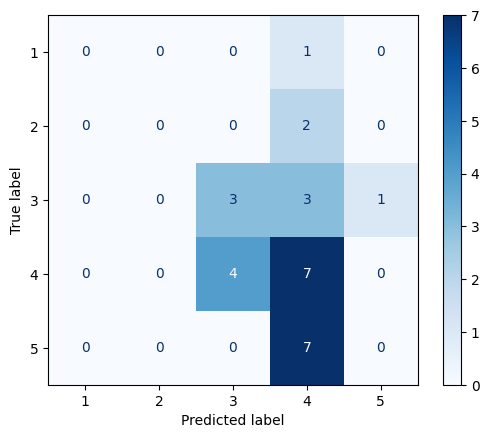

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: Display confusion matrix as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth = 3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [ ]:
y_pred = dt.predict(X_test)

Accuracy: 0.42857142857142855
Confusion Matrix:
 [[1 0 0 0 0]
 [0 1 0 0 1]
 [0 0 0 5 2]
 [0 1 0 5 5]
 [0 0 0 2 5]]


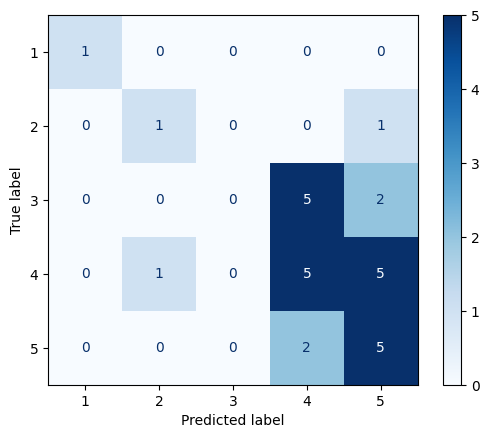

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: Display confusion matrix as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
for i in range(2, 9):
    dt = DecisionTreeClassifier(max_depth=i)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Depth =", i, "Accuracy:", acc)

Depth = 2 Accuracy: 0.42857142857142855
Depth = 3 Accuracy: 0.42857142857142855
Depth = 4 Accuracy: 0.39285714285714285
Depth = 5 Accuracy: 0.35714285714285715
Depth = 6 Accuracy: 0.42857142857142855
Depth = 7 Accuracy: 0.39285714285714285
Depth = 8 Accuracy: 0.39285714285714285
